In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from sklearn import datasets

In [10]:
iris=datasets.load_iris()

In [11]:
df=pd.DataFrame(iris.data)
df.columns=iris.feature_names

In [12]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(df, test_size=0.3, random_state=42)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [18]:
X_test_scaled=scaler.fit_transform(X_test)

In [19]:
X_train_scaled=scaler.fit_transform(X_train)

In [21]:
X_train_scaled.shape

(105, 4)

In [24]:
# doing PCA 
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

In [26]:
pca


,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [30]:
pca_scaled=pca.fit_transform(X_train_scaled)

In [31]:
pca_scaled.shape

(105, 2)

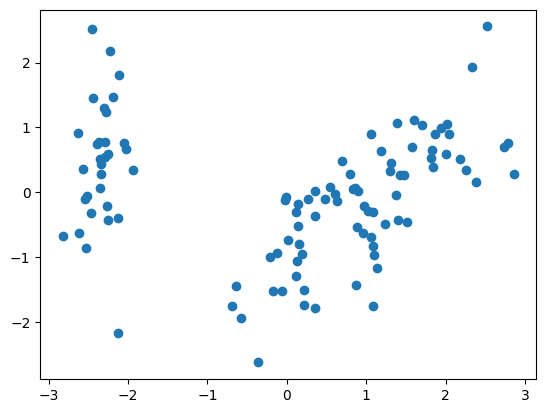

In [37]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1])

Text(0, 0.5, 'Ecludian Distance')

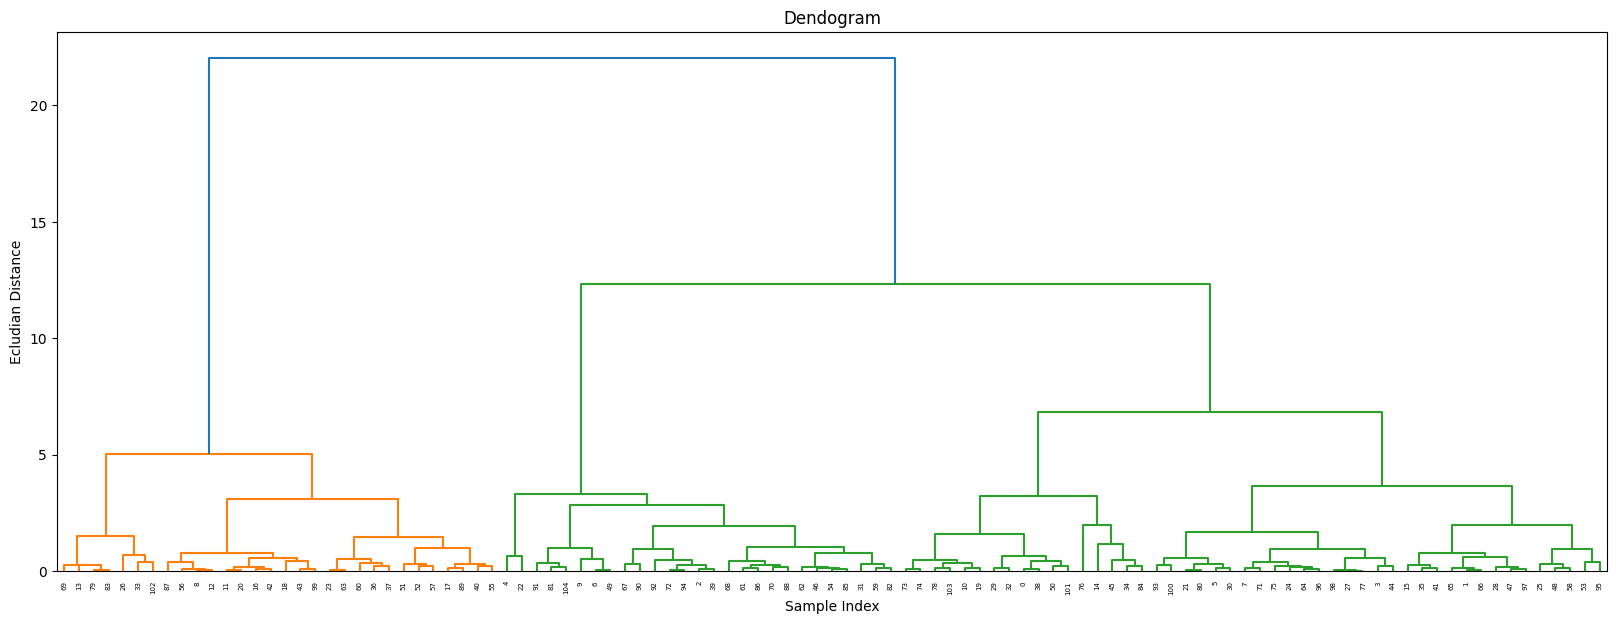

In [44]:
#Agglomrative Clustering
# to construct dendogram 

import scipy.cluster.hierarchy as sc 

plt.figure(figsize=(20,7))
plt.title("Dendograms")

sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title("Dendogram")
plt.xlabel("Sample Index")
plt.ylabel("Ecludian Distance")

In [52]:
from sklearn.cluster import AgglomerativeClustering
cluster=AgglomerativeClustering(n_clusters=2,  linkage='ward')
cluster.fit(pca_scaled)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [53]:
cluster.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

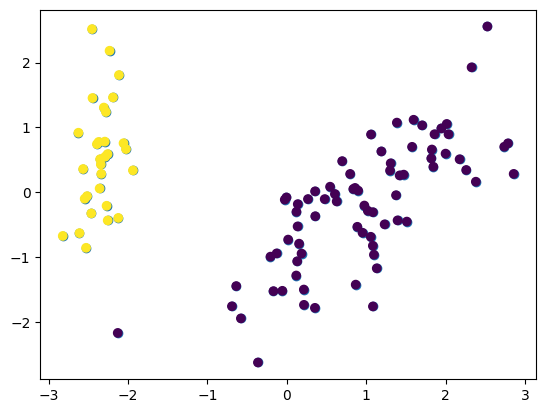

In [54]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1])
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=cluster.labels_)

In [56]:
from sklearn.metrics import silhouette_score

In [68]:
sillhouette_coefficient=[]

for k in range(2,11):
    agglo=AgglomerativeClustering(n_clusters=k, linkage='ward')
    agglo.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled, agglo.labels_)
    sillhouette_coefficient.append(score)


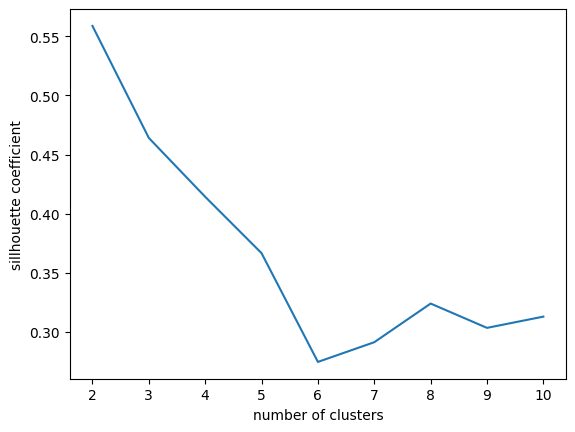

In [69]:
plt.plot(range(2,11),sillhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("sillhouette coefficient")
plt.show()